In [33]:
# Scikit learn
# pip install scikit-learn
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\xampp816\htdocs\personal-dev\py-ds\ML\KNN\diabetes_model\diabetes.csv')
df.head()
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [34]:
# df[df['Glucose']==0]
column_to_handle_zero_values = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in column_to_handle_zero_values:
    print(col)
    print(df[df[col]==0])
    print('\n\n\n')

Glucose
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
75             1        0             48             20        0  24.7   
182            1        0             74             20       23  27.7   
342            1        0             68             35        0  32.0   
349            5        0             80             32        0  41.0   
502            6        0             68             41        0  39.0   

     DiabetesPedigreeFunction  Age  Outcome  
75                      0.140   22        0  
182                     0.299   21        0  
342                     0.389   22        0  
349                     0.346   37        1  
502                     0.727   41        1  




BloodPressure
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
7             10      115              0              0        0  35.3   
15             7      100              0              0        0  30.0   
49             7      105      

In [35]:
column_to_handle_zero_values = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in column_to_handle_zero_values:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

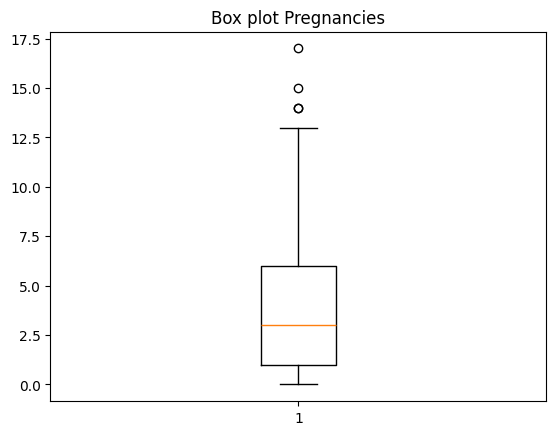

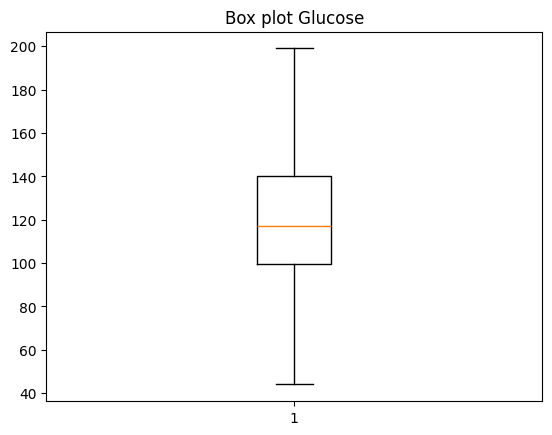

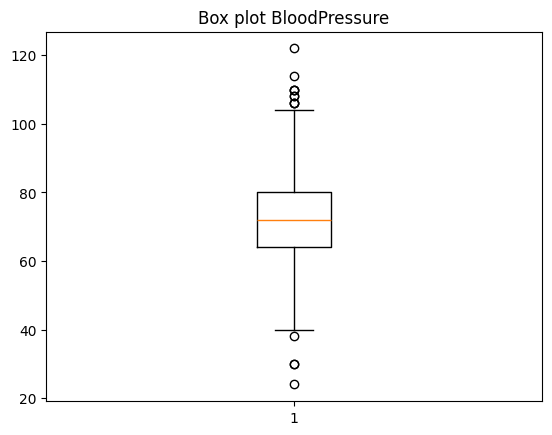

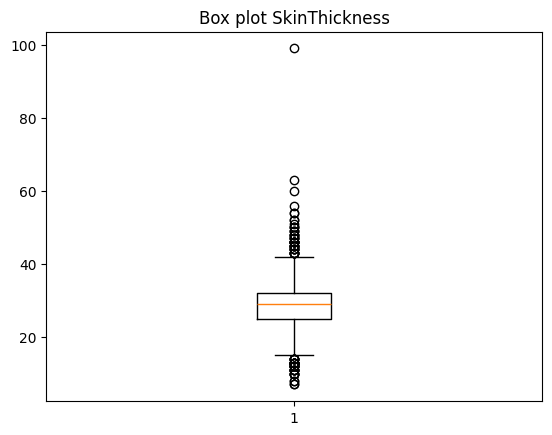

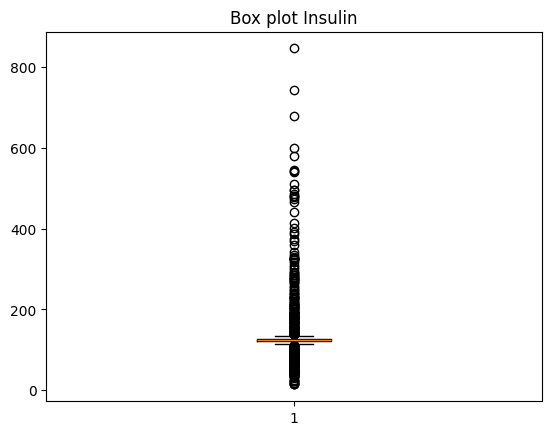

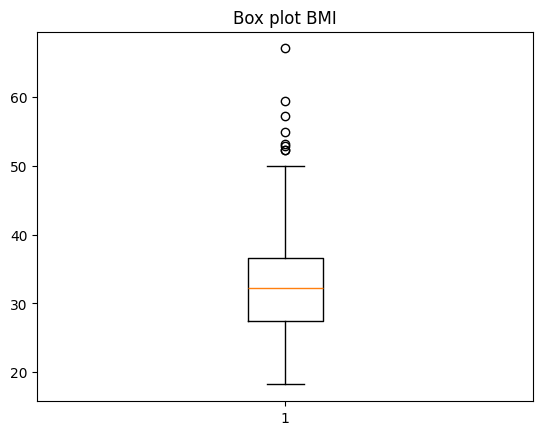

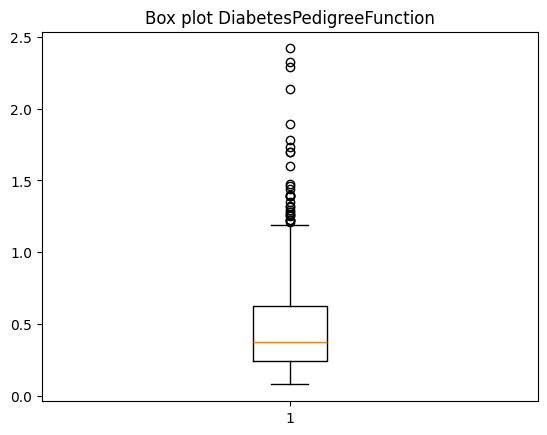

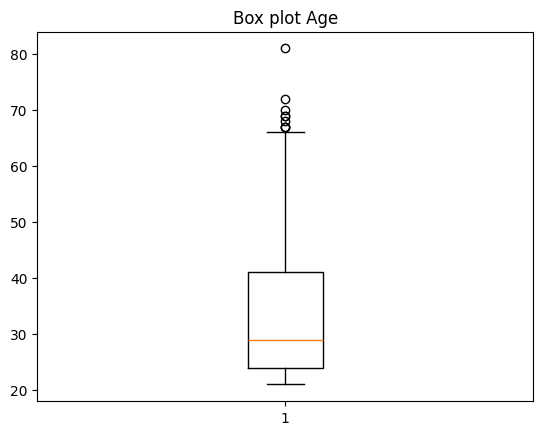

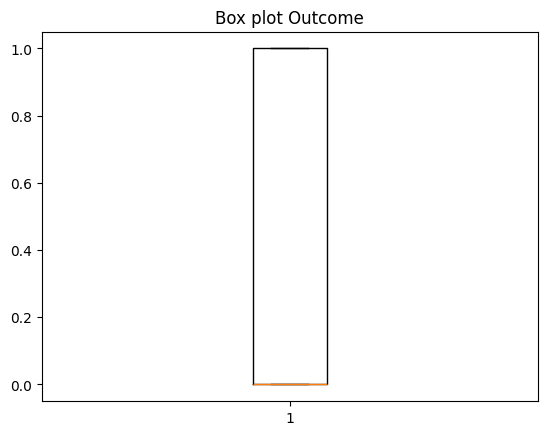

In [36]:
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        plt.boxplot(df[i])
        plt.title(f'Box plot {i}')
        plt.show()

In [37]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [38]:
dict1={}
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        q1=df[i].quantile(0.25)
        q3=df[i].quantile(0.75)
        iqr=q3-q1
        min_range=q1-1.5*iqr
        max_range=q3+1.5*iqr
        dict1[i]=(min_range,max_range)
        # df=df[(df[i]>=min_range) & (df[i]<=max_range) ]
dict1
# print(df[df['Insulin']>=135.875])

print(df[df['Insulin']>=135.875]['Outcome'].value_counts())
print(df[df['BMI']>=50.5]['Outcome'].value_counts())
print(df[df['SkinThickness']>=42.5]['Outcome'].value_counts())
# df=df[df['km_driven']<=dict1['km_driven'][1]]

Outcome
1    87
0    86
Name: count, dtype: int64
Outcome
1    6
0    2
Name: count, dtype: int64
Outcome
1    24
0    24
Name: count, dtype: int64


In [39]:
dict1

{'Pregnancies': (np.float64(-6.5), np.float64(13.5)),
 'Glucose': (np.float64(39.0), np.float64(201.0)),
 'BloodPressure': (np.float64(40.0), np.float64(104.0)),
 'SkinThickness': (np.float64(14.5), np.float64(42.5)),
 'Insulin': (np.float64(112.875), np.float64(135.875)),
 'BMI': (np.float64(13.849999999999998), np.float64(50.25)),
 'DiabetesPedigreeFunction': (np.float64(-0.32999999999999996),
  np.float64(1.2)),
 'Age': (np.float64(-1.5), np.float64(66.5)),
 'Outcome': (np.float64(-1.5), np.float64(2.5))}

In [40]:
df=df[(df['BMI']>=dict1['BMI'][0])&(df['BMI']<=dict1['BMI'][1])]
df=df[(df['SkinThickness']>=dict1['SkinThickness'][0])&(df['SkinThickness']<=dict1['SkinThickness'][1])]

In [41]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
762,9,89.0,62.0,29.0,125.0,22.5,0.142,33,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [42]:
x=df.drop(columns=['Outcome'])
y=df['Outcome']

Scalling

In [43]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
minmax=MinMaxScaler()
x_scaled=minmax.fit_transform(x)

In [49]:
test=[[8, 67, 68, 28, 90, 25, 0.222, 31]]
test_scaled = minmax.transform(test)
test_scaled

c:\Users\rijok\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[0.47058824, 0.14935065, 0.44897959, 0.48148148, 0.08915663,
        0.21656051, 0.06397157, 0.16666667]])

Train Test Split

In [45]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=5)

KNN model training

In [46]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()
model.fit(x_train, y_train)

KNeighborsClassifier()

In [47]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1])

Evaluation

In [48]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred)*100)

69.45812807881774


Use Model

In [53]:
test=[[8, 67, 68, 28, 90, 25, 0.222, 31]]
test_scaled = minmax.transform(test)
# test_scaled

test_scaled_pred = model.predict(test_scaled)
if (test_scaled_pred[0] == 0):
    print("You are not going to be diabetic")
else:
    print("You are going to be diabetic")

You are not going to be diabetic


c:\Users\rijok\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
